# Random Forest Modeling

In [2]:
from sklearn.preprocessing import StandardScaler #statndardize features by removing the mean and scaling to unit variance
from sklearn.model_selection import train_test_split #split arrays or matrices into random train and test subsets
import sys # for manipulating the Python runtime environment
import os # for interacting with the operating system

# Get the current working directory (where the notebook is located)
current_dir = os.getcwd() # Get the current directory

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
# Ensure the parent directory is in sys.path so we can import modules from it
# Add the parent directory to sys.path
sys.path.insert(0, parent_dir)
from field import Field



from data_creator import load_2D
df = load_2D().dropna() # load data from files
#print("Rows before dropna:", load_2D().shape[0])
#print("Rows after dropna:", df.shape[0])
#print(df.isna().sum())

# split data into X and y

X = df[['Area', 'Circumference', 'MU', "Span" ,'CoA','MCS']]#"MCS" and 'CoA' are removed from X temporarily
y = df["AD"]

# # scale X
scale = StandardScaler()
scaled_X = scale.fit_transform(X)

# # train test split
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y, test_size = 0.25, random_state = 4)


In [ ]:

print(df)

             QADate  Unit Energy     MU  DPF  ADPass  RDPass    AD     RD  \
FieldID                                                                     
2401888  12/08/2023  NA12     6X  730.1  400      75      90  97.9  100.0   
2401842  12/08/2023  NA12     6X  264.8  180      75      90  94.6   98.5   
2401965  12/08/2023  NA12     6X  601.7  400      75      90  94.5   99.9   
2401841  12/08/2023  NA12     6X  316.1    0      75      90  96.9   97.7   
2401960  12/08/2023  NA12     6X  587.8  600      75      90  96.8   99.8   
...             ...   ...    ...    ...  ...     ...     ...   ...    ...   
2404678  12/20/2023  EV06     6X  130.0  180      85      95  99.5  100.0   
2403208  12/20/2023  EV06     6X  264.0  250      83      95  96.6   99.9   
2403209  12/20/2023  EV06     6X  267.0  250      83      95  97.0   99.8   
2404652  12/20/2023  EV06     6X  177.0  200      83      95  97.9   99.7   
2404653  12/20/2023  EV06     6X  208.0  200      83      95  98.2   99.4   

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# initialize random forest classifier
rfc = RandomForestRegressor()

# tune random forest parameters
param_grid = {
    'n_estimators':[5,10,15,20],
    'max_depth':[2,5,7,9]
}
grid_clf = GridSearchCV(rfc, param_grid, cv=10)
grid_clf.fit(X_train, y_train)

# fit final random forest model
final = RandomForestRegressor(n_estimators = grid_clf.best_params_["n_estimators"],
 max_depth = grid_clf.best_params_["max_depth"])
final.fit(X_train, y_train)

RandomForestRegressor(max_depth=9, n_estimators=20)

### Results

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict & Evaluate
y_pred = final.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [9]:

print( "Random Forest Regressor Results:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

Random Forest Regressor Results:
RMSE: 5.1002
MAE : 3.9162
R²  : 0.5591


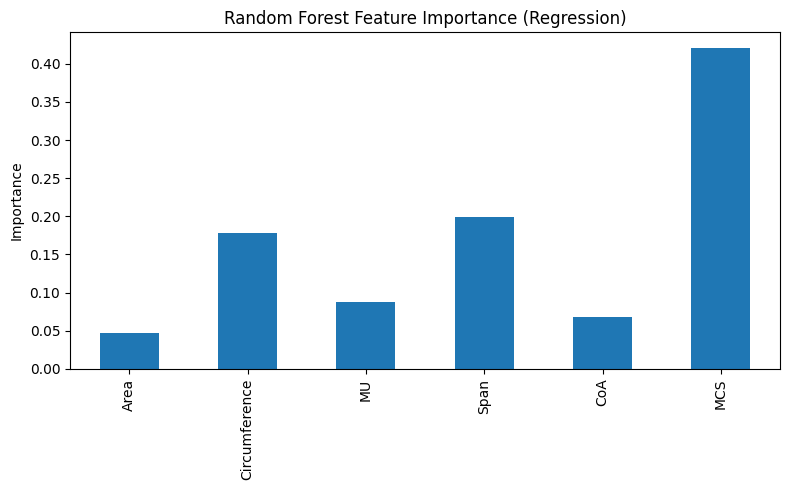

In [11]:


import pandas as pd

feature_names = X.columns
importances = final.feature_importances_
forest_importances = pd.Series(importances, index=feature_names)

plt.figure(figsize=(8, 5))
forest_importances.plot.bar()
plt.title("Random Forest Feature Importance (Regression)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


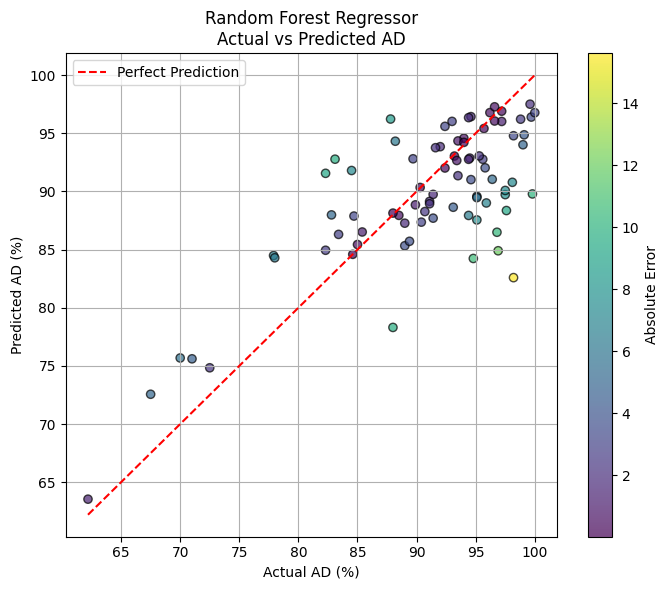

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute absolute error
errors = np.abs(y_test - y_pred)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(y_test, y_pred, c=errors, cmap="viridis", alpha=0.7, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')

# Labels and aesthetics
plt.xlabel("Actual AD (%)")
plt.ylabel("Predicted AD (%)")
plt.title("Random Forest Regressor\nActual vs Predicted AD")
plt.colorbar(scatter, label="Absolute Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
